In [1]:
from google.colab import files
uploaded = files.upload()
# Select BOTH files at once from your Desktop

Saving data_clinical_patient.txt to data_clinical_patient.txt
Saving data_clinical_sample.txt to data_clinical_sample.txt


In [2]:
import pandas as pd

clinical = pd.read_csv("data_clinical_patient.txt", sep="\t", comment="#")
samples  = pd.read_csv("data_clinical_sample.txt",  sep="\t", comment="#")

print("Clinical shape:", clinical.shape)
print("\nClinical columns:")
print(clinical.columns.tolist())

Clinical shape: (2509, 24)

Clinical columns:
['PATIENT_ID', 'LYMPH_NODES_EXAMINED_POSITIVE', 'NPI', 'CELLULARITY', 'CHEMOTHERAPY', 'COHORT', 'ER_IHC', 'HER2_SNP6', 'HORMONE_THERAPY', 'INFERRED_MENOPAUSAL_STATE', 'SEX', 'INTCLUST', 'AGE_AT_DIAGNOSIS', 'OS_MONTHS', 'OS_STATUS', 'CLAUDIN_SUBTYPE', 'THREEGENE', 'VITAL_STATUS', 'LATERALITY', 'RADIO_THERAPY', 'HISTOLOGICAL_SUBTYPE', 'BREAST_SURGERY', 'RFS_MONTHS', 'RFS_STATUS']


In [3]:
import numpy as np

# ── Subtype distribution ──
print("=== CLAUDIN_SUBTYPE ===")
print(clinical["CLAUDIN_SUBTYPE"].value_counts())

# ── Survival status format ──
print("\n=== OS_STATUS unique values ===")
print(clinical["OS_STATUS"].unique())

print("\n=== RFS_STATUS unique values ===")
print(clinical["RFS_STATUS"].unique())

# ── Missing values in key columns ──
key_cols = ["OS_MONTHS", "OS_STATUS", "RFS_MONTHS", "RFS_STATUS",
            "CLAUDIN_SUBTYPE", "AGE_AT_DIAGNOSIS",
            "LYMPH_NODES_EXAMINED_POSITIVE", "NPI"]

print("\n=== Missing Values ===")
print(clinical[key_cols].isnull().sum())

# ── Basic survival stats ──
print("\n=== OS_MONTHS summary ===")
print(clinical["OS_MONTHS"].describe())

=== CLAUDIN_SUBTYPE ===
CLAUDIN_SUBTYPE
LumA           700
LumB           475
Her2           224
claudin-low    218
Basal          209
Normal         148
NC               6
Name: count, dtype: int64

=== OS_STATUS unique values ===
['0:LIVING' '1:DECEASED' nan]

=== RFS_STATUS unique values ===
['0:Not Recurred' '1:Recurred' nan]

=== Missing Values ===
OS_MONTHS                        528
OS_STATUS                        528
RFS_MONTHS                       121
RFS_STATUS                        21
CLAUDIN_SUBTYPE                  529
AGE_AT_DIAGNOSIS                  11
LYMPH_NODES_EXAMINED_POSITIVE    266
NPI                              222
dtype: int64

=== OS_MONTHS summary ===
count    1981.000000
mean      125.244271
std        76.111772
min         0.000000
25%        60.866667
50%       116.466667
75%       185.133333
max       355.200000
Name: OS_MONTHS, dtype: float64


In [4]:
import pandas as pd
import numpy as np

# ── 1. Keep only subtypes matching our GSE45827 classifier ──
subtype_map = {
    "LumA":  "Luminal A",
    "LumB":  "Luminal B",
    "Her2":  "Her2",
    "Basal": "Basal"
}

df = clinical[clinical["CLAUDIN_SUBTYPE"].isin(subtype_map.keys())].copy()
df["SUBTYPE"] = df["CLAUDIN_SUBTYPE"].map(subtype_map)

# ── 2. Encode OS_STATUS → binary integer ──
df["OS_EVENT"] = df["OS_STATUS"].str[0].astype(float)

# ── 3. Encode RFS_STATUS → binary integer ──
df["RFS_EVENT"] = df["RFS_STATUS"].str[0].astype(float)

# ── 4. Drop rows missing OS data ──
df = df.dropna(subset=["OS_MONTHS", "OS_EVENT"])

# ── 5. Fill or drop key covariate missings ──
df["AGE_AT_DIAGNOSIS"]           = pd.to_numeric(df["AGE_AT_DIAGNOSIS"], errors="coerce")
df["LYMPH_NODES_EXAMINED_POSITIVE"] = pd.to_numeric(df["LYMPH_NODES_EXAMINED_POSITIVE"], errors="coerce")
df["NPI"]                        = pd.to_numeric(df["NPI"], errors="coerce")

# ── 6. Final check ──
print("Final cohort shape:", df.shape)
print("\nSubtype distribution:")
print(df["SUBTYPE"].value_counts())
print("\nOS_EVENT distribution:")
print(df["OS_EVENT"].value_counts())
print("\nMissing in key columns:")
print(df[["OS_MONTHS", "OS_EVENT", "RFS_MONTHS", "RFS_EVENT",
          "AGE_AT_DIAGNOSIS", "LYMPH_NODES_EXAMINED_POSITIVE", "NPI"]].isnull().sum())
print("\nSample rows:")
print(df[["PATIENT_ID", "SUBTYPE", "OS_MONTHS", "OS_EVENT", "AGE_AT_DIAGNOSIS"]].head())

Final cohort shape: (1608, 27)

Subtype distribution:
SUBTYPE
Luminal A    700
Luminal B    475
Her2         224
Basal        209
Name: count, dtype: int64

OS_EVENT distribution:
OS_EVENT
1.0    965
0.0    643
Name: count, dtype: int64

Missing in key columns:
OS_MONTHS                         0
OS_EVENT                          0
RFS_MONTHS                        0
RFS_EVENT                         1
AGE_AT_DIAGNOSIS                  0
LYMPH_NODES_EXAMINED_POSITIVE    49
NPI                               0
dtype: int64

Sample rows:
  PATIENT_ID    SUBTYPE   OS_MONTHS  OS_EVENT  AGE_AT_DIAGNOSIS
1    MB-0002  Luminal A   84.633333       0.0             43.19
2    MB-0005  Luminal B  163.700000       1.0             48.87
3    MB-0006  Luminal B  164.933333       0.0             47.68
4    MB-0008  Luminal B   41.366667       1.0             76.97
5    MB-0010  Luminal B    7.800000       1.0             78.77


In [5]:
#Phase 2: Pull Biomarker Gene Expression via API
import requests
import pandas as pd

BASE  = "https://www.cbioportal.org/api"
STUDY = "brca_metabric"

# ── Step 1: Confirm the expression profile ID ──
print("=== MOLECULAR PROFILES ===")
profiles = requests.get(f"{BASE}/studies/{STUDY}/molecular-profiles").json()
for p in profiles:
    print(p["molecularProfileId"], "→", p["name"])

=== MOLECULAR PROFILES ===
brca_metabric_cna → Putative copy-number alterations from DNAcopy.
brca_metabric_methylation_promoters_rrbs → Promoter methylation (RRBS)
brca_metabric_mrna → mRNA expression (Illumina HT-12 v3 microarray)
brca_metabric_mrna_median_all_sample_Zscores → mRNA expression z-scores relative to all samples (log microarray)
brca_metabric_mutations → Mutations


In [ ]:
import requests
import pandas as pd

BASE     = "https://www.cbioportal.org/api"
STUDY    = "brca_metabric"
PROFILE  = "brca_metabric_mrna_median_all_sample_Zscores"

# ── Your biomarker genes from the GSE45827 project ──
#full gene_symbols list from the previous notebook(breast-cancer-subtype-classification.ipynb)
biomarker_genes = [
'PTTG1', 'KIF14', 'ASPM', 'CENPE', 'MLPH', 'CACYBP', 'STARD10', 'EZH2',
 'ERBB2', 'WFS1', 'AURKA', 'CENPA', 'SLC35F6', 'CDCA3', 'CCNB2', 'MND1',
 'UBE2T', 'NME3', 'SUV39H2', 'GRB7', 'AGR2', 'CDCA5', 'CEP126', 'MYBL2',
 'CDC6', 'SPDEF', 'SPAG5', 'BUB1', 'IL6ST', 'ESR1', 'GATA3', 'SMIM13', 'AURKB',
 'EME2', 'GABRP', 'BTG3', 'CFAP69', 'CMC2', 'GPN1', 'FOXM1', 'ZNF740', 'ABAT',
 'LRRC37A2', 'LRRC37A4P', 'SRSF5', 'CA12']
    #actual full list from gene_symbols variable


# ── Step 1: Convert gene symbols → Entrez IDs ──
gene_resp = requests.post(
    f"{BASE}/genes/fetch?geneIdType=HUGO_GENE_SYMBOL",
    json=biomarker_genes
).json()

entrez_ids  = [g["entrezGeneId"] for g in gene_resp]
found_genes = [g["hugoGeneSymbol"] for g in gene_resp]
print(f"Genes requested: {len(biomarker_genes)}")
print(f"Genes found in cBioPortal: {len(found_genes)}")
print("Found:", found_genes)

# ── Step 2: Get all sample IDs for METABRIC ──
samples_resp = requests.get(
    f"{BASE}/studies/{STUDY}/samples?projection=ID"
).json()
all_sample_ids = [s["sampleId"] for s in samples_resp]
print(f"\nTotal METABRIC samples: {len(all_sample_ids)}")

# ── Step 3: Filter to only our 1,608 clean cohort patients ──
# METABRIC sample IDs match patient IDs directly (MB-XXXX)
cohort_patient_ids = set(df["PATIENT_ID"].tolist())
cohort_sample_ids  = [s for s in all_sample_ids if s in cohort_patient_ids]
print(f"Cohort sample IDs matched: {len(cohort_sample_ids)}")

# ── Step 4: Fetch expression values ──
payload = {
    "entrezGeneIds": entrez_ids,
    "sampleIds":     cohort_sample_ids
}
expr_resp = requests.post(
    f"{BASE}/molecular-profiles/{PROFILE}/molecular-data/fetch?projection=SUMMARY",
    json=payload
).json()

expr_df = pd.DataFrame(expr_resp)
print(f"\nExpression data shape (long format): {expr_df.shape}")
print(expr_df.head())

Genes requested: 46
Genes found in cBioPortal: 46
Found: ['ABAT', 'AGR2', 'ASPM', 'AURKA', 'AURKB', 'BTG3', 'BUB1', 'CA12', 'CACYBP', 'CCNB2', 'CDC6', 'CDCA3', 'CDCA5', 'CENPA', 'CENPE', 'CEP126', 'CFAP69', 'CMC2', 'EME2', 'ERBB2', 'ESR1', 'EZH2', 'FOXM1', 'GABRP', 'GATA3', 'GPN1', 'GRB7', 'IL6ST', 'KIF14', 'LRRC37A2', 'LRRC37A4P', 'MLPH', 'MND1', 'MYBL2', 'NME3', 'PTTG1', 'SLC35F6', 'SMIM13', 'SPAG5', 'SPDEF', 'SRSF5', 'STARD10', 'SUV39H2', 'UBE2T', 'WFS1', 'ZNF740']

Total METABRIC samples: 2509
Cohort sample IDs matched: 1608

Expression data shape (long format): (73968, 8)
                uniqueSampleKey              uniquePatientKey  entrezGeneId  \
0  TUItMDAwMjpicmNhX21ldGFicmlj  TUItMDAwMjpicmNhX21ldGFicmlj            18   
1  TUItMDAwMjpicmNhX21ldGFicmlj  TUItMDAwMjpicmNhX21ldGFicmlj         10551   
2  TUItMDAwMjpicmNhX21ldGFicmlj  TUItMDAwMjpicmNhX21ldGFicmlj          2146   
3  TUItMDAwMjpicmNhX21ldGFicmlj  TUItMDAwMjpicmNhX21ldGFicmlj          2305   
4  TUItMDAwMjpicmNhX2

In [8]:
# ── Fix: Build Entrez ID → Gene Symbol mapping ──
entrez_to_symbol = {g["entrezGeneId"]: g["hugoGeneSymbol"] for g in gene_resp}

# Rename expression columns from Entrez IDs to gene symbols
expr_wide_named = expr_wide.copy()
expr_wide_named.columns = [
    entrez_to_symbol.get(int(c), c) if str(c).isdigit() else c
    for c in expr_wide_named.columns
]

print("Renamed columns sample:")
print(expr_wide_named.columns.tolist()[:10])

# ── Re-merge with named columns ──
merged = df.merge(expr_wide_named, on="PATIENT_ID", how="inner")

# ── Now gene_cols will correctly find all 46 genes ──
gene_cols = [c for c in merged.columns if c in found_genes]
print(f"\nGene columns confirmed: {len(gene_cols)}")
print("Gene columns:", gene_cols[:10], "...")

# ── Final clean ──
merged_clean = merged.dropna(subset=gene_cols)
print(f"\nFinal analysis cohort: {merged_clean.shape}")
print(f"OS events: {merged_clean['OS_EVENT'].sum():.0f} deaths / {len(merged_clean)} patients")

# ── Save to CSV as checkpoint ──
merged_clean.to_csv("metabric_survival_analysis.csv", index=False)
print("\n✅ Saved: metabric_survival_analysis.csv")

Renamed columns sample:
['PATIENT_ID', 'ABAT', 'BUB1', 'CA12', 'CDC6', 'CENPA', 'CENPE', 'ERBB2', 'ESR1', 'EZH2']

Gene columns confirmed: 46
Gene columns: ['ABAT', 'BUB1', 'CA12', 'CDC6', 'CENPA', 'CENPE', 'ERBB2', 'ESR1', 'EZH2', 'FOXM1'] ...

Final analysis cohort: (1608, 73)
OS events: 965 deaths / 1608 patients

✅ Saved: metabric_survival_analysis.csv


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 13.7 MB/s eta 0:00:00


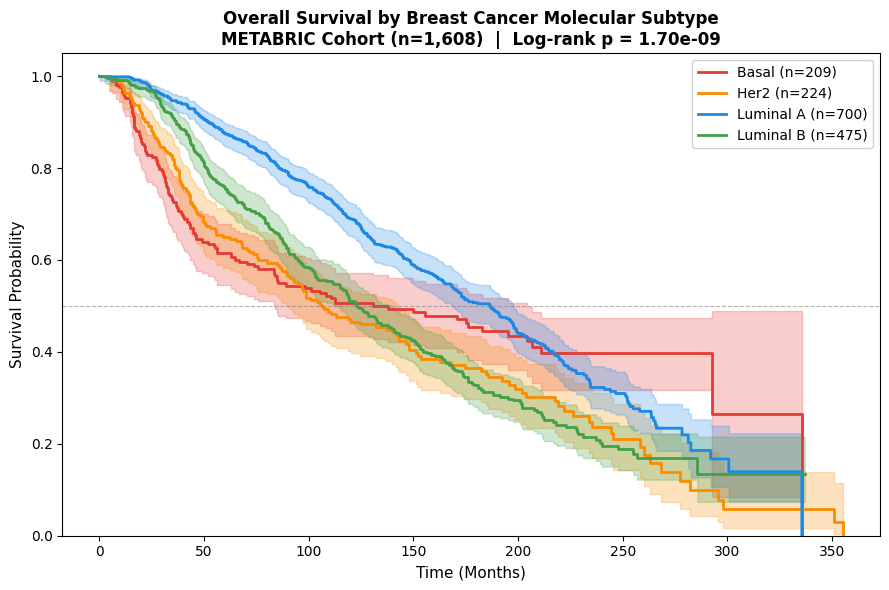


Log-rank test p-value: 1.70e-09
Test statistic: 43.7518


In [9]:
#Phase 3: Kaplan-Meier Survival Curves
!pip install lifelines --quiet

from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test
import matplotlib.pyplot as plt
import numpy as np

# ── Subtype colours matching your previous project ──
palette = {
    "Basal":     "#E53935",
    "Her2":      "#FB8C00",
    "Luminal A": "#1E88E5",
    "Luminal B": "#43A047"
}

fig, ax = plt.subplots(figsize=(9, 6))
kmf = KaplanMeierFitter()

for subtype, color in palette.items():
    mask = merged_clean["SUBTYPE"] == subtype
    kmf.fit(
        merged_clean.loc[mask, "OS_MONTHS"],
        merged_clean.loc[mask, "OS_EVENT"],
        label=f"{subtype} (n={mask.sum()})"
    )
    kmf.plot_survival_function(ax=ax, color=color, ci_show=True, linewidth=2)

# ── Log-rank test (all 4 subtypes) ──
logrank = multivariate_logrank_test(
    merged_clean["OS_MONTHS"],
    merged_clean["SUBTYPE"],
    merged_clean["OS_EVENT"]
)

ax.set_title(
    f"Overall Survival by Breast Cancer Molecular Subtype\n"
    f"METABRIC Cohort (n=1,608)  |  Log-rank p = {logrank.p_value:.2e}",
    fontsize=12, fontweight="bold"
)
ax.set_xlabel("Time (Months)", fontsize=11)
ax.set_ylabel("Survival Probability", fontsize=11)
ax.set_ylim(0, 1.05)
ax.legend(loc="upper right", fontsize=10, framealpha=0.9)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.savefig("KM_survival_by_subtype.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nLog-rank test p-value: {logrank.p_value:.2e}")
print(f"Test statistic: {logrank.test_statistic:.4f}")

In [10]:
#Multivariate Cox Regression
from lifelines import CoxPHFitter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Encode subtype as dummy variables (Luminal A as reference) ──
cox_df = merged_clean.copy()
cox_df = pd.get_dummies(cox_df, columns=["SUBTYPE"], drop_first=False)
cox_df = cox_df.drop(columns=["SUBTYPE_Luminal A"])  # reference category

# ── Select Cox input columns ──
clinical_covariates = [
    "AGE_AT_DIAGNOSIS",
    "LYMPH_NODES_EXAMINED_POSITIVE",
    "NPI",
    "SUBTYPE_Basal",
    "SUBTYPE_Her2",
    "SUBTYPE_Luminal B"
]

# Fill remaining missing in lymph nodes with median
cox_df["LYMPH_NODES_EXAMINED_POSITIVE"] = cox_df["LYMPH_NODES_EXAMINED_POSITIVE"].fillna(
    cox_df["LYMPH_NODES_EXAMINED_POSITIVE"].median()
)

# ── Model 1: Clinical only (baseline) ──
cols_clinical = clinical_covariates + ["OS_MONTHS", "OS_EVENT"]
cph_clinical = CoxPHFitter(penalizer=0.1)
cph_clinical.fit(
    cox_df[cols_clinical],
    duration_col="OS_MONTHS",
    event_col="OS_EVENT"
)
print("=== MODEL 1: Clinical Variables Only ===")
cph_clinical.print_summary(decimals=4)
print(f"Concordance Index: {cph_clinical.concordance_index_:.4f}")

# ── Model 2: Clinical + Biomarker Genes ──
cols_full = clinical_covariates + gene_cols + ["OS_MONTHS", "OS_EVENT"]
cph_full = CoxPHFitter(penalizer=0.1)
cph_full.fit(
    cox_df[cols_full],
    duration_col="OS_MONTHS",
    event_col="OS_EVENT"
)
print("\n=== MODEL 2: Clinical + Biomarker Genes ===")
cph_full.print_summary(decimals=4)
print(f"Concordance Index: {cph_full.concordance_index_:.4f}")

# ── Compare C-index improvement ──
print("\n=== MODEL COMPARISON ===")
print(f"Clinical only     C-index: {cph_clinical.concordance_index_:.4f}")
print(f"Clinical + Genes  C-index: {cph_full.concordance_index_:.4f}")
print(f"Improvement:              +{cph_full.concordance_index_ - cph_clinical.concordance_index_:.4f}")

=== MODEL 1: Clinical Variables Only ===


<lifelines.CoxPHFitter: fitted with 1608 total observations, 643 right-censored observations>
             duration col = 'OS_MONTHS'
                event col = 'OS_EVENT'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 1608
number of events observed = 965
   partial log-likelihood = -6285.6133
         time fit was run = 2026-06-26 03:05:13 UTC

---
                                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                       
AGE_AT_DIAGNOSIS              0.0304    1.0309    0.0026          0.0252          0.0356              1.0255              1.0362
LYMPH_NODES_EXAMINED_POSITIVE 0.0409    1.0417    0.0064          0.0283          0.0535              1.0287              1.0550
NPI                           0.1626    1.1766    0.0302          0.1035          0.2218              1.1090              1.2483
SUBTYPE_Basal                 0.2540    1.2892    0.0996          0.0588          0.4492              1.0606              1.5670
SUBTYPE_Her2                  0.3504    1.4196    0.0887          0.1765          0.5242              1.1931              1.6891
SUBTYPE_Luminal B             0.1796    1.1968    0.0695          0.0433          0.3159              1.0443              1.3715

                               cmp to       z      p  -log2(p)
covariate                                                     
AGE_AT_DIAGNOSIS               0.0000 11.5174 <5e-05   99.5498
LYMPH_NODES_EXAMINED_POSITIVE  0.0000  6.3585 <5e-05   32.1926
NPI                            0.0000  5.3860 <5e-05   23.7263
SUBTYPE_Basal                  0.0000  2.5508 0.0107    6.5398
SUBTYPE_Her2                   0.0000  3.9504 0.0001   13.6458
SUBTYPE_Luminal B              0.0000  2.5831 0.0098    6.6741
---
Concordance = 0.6567
Partial AIC = 12583.2266
log-likelihood ratio test = 265.2049 on 6 df
-log2(p) of ll-ratio test = 178.1812

Concordance Index: 0.6567

=== MODEL 2: Clinical + Biomarker Genes ===


<lifelines.CoxPHFitter: fitted with 1608 total observations, 643 right-censored observations>
             duration col = 'OS_MONTHS'
                event col = 'OS_EVENT'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 1608
number of events observed = 965
   partial log-likelihood = -6256.6184
         time fit was run = 2026-06-26 03:05:15 UTC

---
                                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                        
AGE_AT_DIAGNOSIS               0.0322    1.0327    0.0028          0.0267          0.0377              1.0270              1.0384
LYMPH_NODES_EXAMINED_POSITIVE  0.0462    1.0473    0.0069          0.0326          0.0598              1.0332              1.0617
NPI                            0.1290    1.1377    0.0316          0.0670          0.1910              1.0693              1.2105
SUBTYPE_Basal                 -0.0294    0.9710    0.1547         -0.3326          0.2738              0.7171              1.3149
SUBTYPE_Her2                   0.1354    1.1450    0.1189         -0.0977          0.3685              0.9069              1.4456
SUBTYPE_Luminal B              0.1198    1.1273    0.0866         -0.0499          0.2896              0.9513              1.3358
ABAT                          -0.0712    0.9313    0.0382         -0.1460          0.0036              0.8642              1.0036
BUB1                           0.0304    1.0309    0.0570         -0.0812          0.1421              0.9220              1.1526
CA12                           0.0150    1.0152    0.0504         -0.0838          0.1139              0.9196              1.1206
CDC6                          -0.0407    0.9602    0.0347         -0.1087          0.0274              0.8970              1.0277
CENPA                         -0.0552    0.9463    0.0609         -0.1746          0.0643              0.8398              1.0664
CENPE                          0.0301    1.0305    0.0527         -0.0732          0.1333              0.9294              1.1426
ERBB2                          0.0054    1.0054    0.0514         -0.0953          0.1061              0.9091              1.1119
ESR1                          -0.0231    0.9771    0.0553         -0.1316          0.0853              0.8767              1.0891
EZH2                          -0.0505    0.9507    0.0449         -0.1385          0.0374              0.8707              1.0381
FOXM1                          0.0344    1.0350    0.0564         -0.0761          0.1449              0.9268              1.1559
GABRP                          0.0764    1.0794    0.0489         -0.0194          0.1722              0.9808              1.1879
GATA3                         -0.0437    0.9572    0.0551         -0.1516          0.0642              0.8593              1.0663
GRB7                           0.0806    1.0840    0.0491         -0.0156          0.1768              0.9846              1.1934
IL6ST                          0.0013    1.0013    0.0436         -0.0842          0.0869              0.9192              1.0908
MYBL2                         -0.0251    0.9752    0.0311         -0.0860          0.0359              0.9176              1.0365
NME3                          -0.0642    0.9378    0.0439         -0.1502          0.0219              0.8605              1.0221
SRSF5                          0.0628    1.0649    0.0357         -0.0071          0.1328              0.9929              1.1420
AURKA                          0.0480    1.0491    0.0525         -0.0550          0.1509              0.9465              1.1629
WFS1                          -0.0345    0.9660    0.0413         -0.1155          0.0464              0.8909              1.0475
CCNB2                         -0.0023    0.9977    0.059

Concordance Index: 0.6788

=== MODEL COMPARISON ===
Clinical only     C-index: 0.6567
Clinical + Genes  C-index: 0.6788
Improvement:              +0.0221


In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

# ── Extract full Cox results from Model 2 ──
cox_summary = cph_full.summary.copy()
cox_summary.columns = cox_summary.columns.str.strip()
cox_summary = cox_summary.reset_index()
cox_summary.columns.values[0] = "variable"

print("Columns:", cox_summary.columns.tolist())
print(cox_summary.head(3))

Columns: ['variable', 'coef', 'exp(coef)', 'se(coef)', 'coef lower 95%', 'coef upper 95%', 'exp(coef) lower 95%', 'exp(coef) upper 95%', 'cmp to', 'z', 'p', '-log2(p)']
                        variable      coef  exp(coef)  se(coef)  \
0               AGE_AT_DIAGNOSIS  0.032175   1.032698  0.002813   
1  LYMPH_NODES_EXAMINED_POSITIVE  0.046241   1.047327  0.006936   
2                            NPI  0.129022   1.137715  0.031645   

   coef lower 95%  coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%  \
0        0.026661        0.037689             1.027019             1.038408   
1        0.032647        0.059835             1.033186             1.061661   
2        0.067000        0.191045             1.069295             1.210513   

   cmp to          z             p   -log2(p)  
0     0.0  11.436260  2.755064e-30  98.195757  
1     0.0   6.667055  2.609879e-11  35.157226  
2     0.0   4.077226  4.557615e-05  14.421361  


In [12]:
# ── Identify significant biomarker genes ──
gene_results = cox_summary[cox_summary["variable"].isin(gene_cols)].copy()
sig_genes = gene_results[gene_results["p"] < 0.05].sort_values("p")

print("=== SIGNIFICANT BIOMARKER GENES (p < 0.05) ===")
print(sig_genes[["variable", "coef", "exp(coef)", "p"]].to_string())

print("\n=== BORDERLINE SIGNIFICANT (p < 0.10) ===")
borderline = gene_results[(gene_results["p"] >= 0.05) & (gene_results["p"] < 0.10)]
print(borderline[["variable", "coef", "exp(coef)", "p"]].to_string())

=== SIGNIFICANT BIOMARKER GENES (p < 0.05) ===
   variable      coef  exp(coef)         p
46    CDCA5  0.134328   1.143768  0.022631
39     CMC2 -0.084352   0.919107  0.049480

=== BORDERLINE SIGNIFICANT (p < 0.10) ===
   variable      coef  exp(coef)         p
6      ABAT -0.071206   0.931270  0.062034
22    SRSF5  0.062836   1.064852  0.078437
29     AGR2  0.075307   1.078215  0.056108
45     MND1 -0.074768   0.927959  0.074560


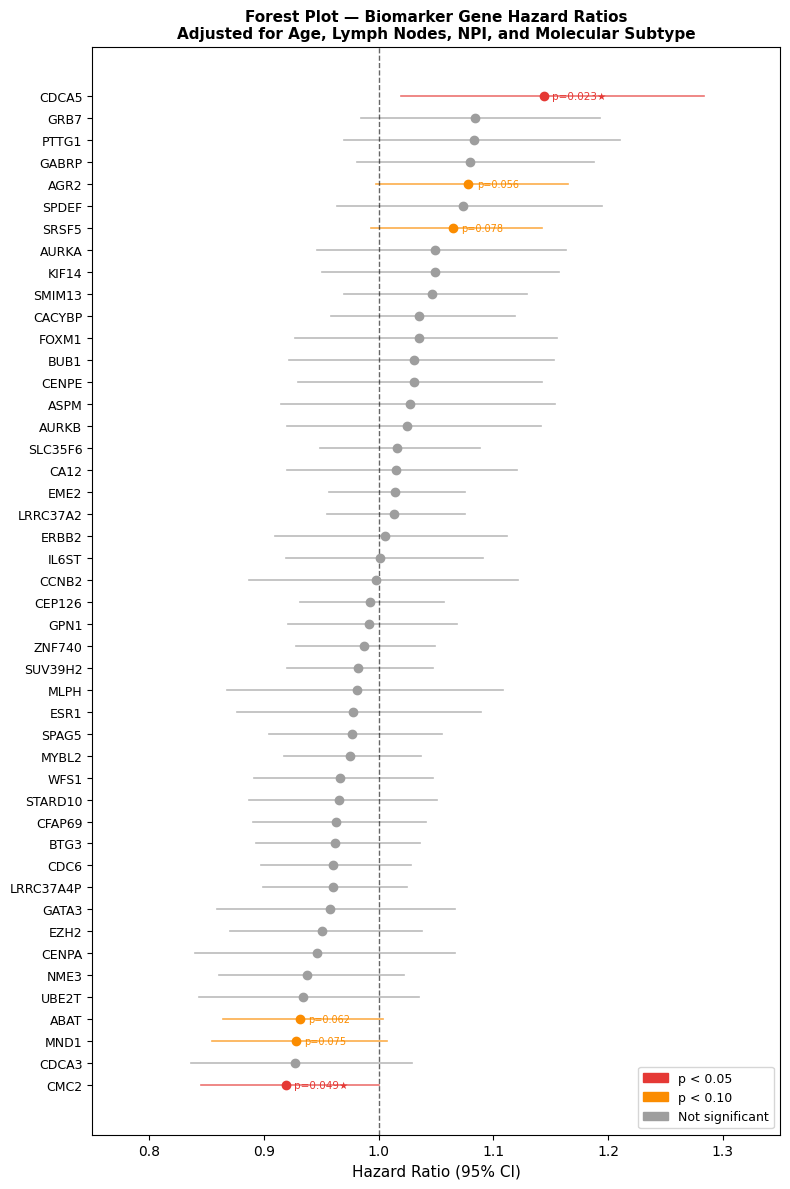

In [13]:
#Figure1-ForestPlot
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Prepare gene-only results ──
forest_df = gene_results.copy().sort_values("coef", ascending=True)

hr     = forest_df["exp(coef)"].values
hr_lo  = forest_df["exp(coef) lower 95%"].values
hr_hi  = forest_df["exp(coef) upper 95%"].values
genes  = forest_df["variable"].values
pvals  = forest_df["p"].values

# ── Colour: red = significant, orange = borderline, grey = NS ──
colors = []
for p in pvals:
    if p < 0.05:
        colors.append("#E53935")
    elif p < 0.10:
        colors.append("#FB8C00")
    else:
        colors.append("#9E9E9E")

fig, ax = plt.subplots(figsize=(8, 12))
y_pos = np.arange(len(genes))

# Error bars (CI)
for i, (h, lo, hi, c) in enumerate(zip(hr, hr_lo, hr_hi, colors)):
    ax.plot([lo, hi], [i, i], color=c, linewidth=1.2, alpha=0.7)
    ax.plot(h, i, "o", color=c, markersize=6, zorder=5)

# Reference line at HR=1
ax.axvline(x=1.0, color="black", linestyle="--", linewidth=1, alpha=0.6)

# Annotations for significant genes
for i, (gene, p, h) in enumerate(zip(genes, pvals, hr)):
    if p < 0.05:
        ax.annotate(f"p={p:.3f}★", xy=(h, i),
                    xytext=(6, 0), textcoords="offset points",
                    fontsize=7.5, color="#E53935", va="center")
    elif p < 0.10:
        ax.annotate(f"p={p:.3f}", xy=(h, i),
                    xytext=(6, 0), textcoords="offset points",
                    fontsize=7, color="#FB8C00", va="center")

ax.set_yticks(y_pos)
ax.set_yticklabels(genes, fontsize=9)
ax.set_xlabel("Hazard Ratio (95% CI)", fontsize=11)
ax.set_title(
    "Forest Plot — Biomarker Gene Hazard Ratios\n"
    "Adjusted for Age, Lymph Nodes, NPI, and Molecular Subtype",
    fontsize=11, fontweight="bold"
)

# Legend
legend_elements = [
    mpatches.Patch(color="#E53935", label="p < 0.05"),
    mpatches.Patch(color="#FB8C00", label="p < 0.10"),
    mpatches.Patch(color="#9E9E9E", label="Not significant"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)
ax.set_xlim(0.75, 1.35)

plt.tight_layout()
plt.savefig("forest_plot_biomarkers.png", dpi=150, bbox_inches="tight")
plt.show()

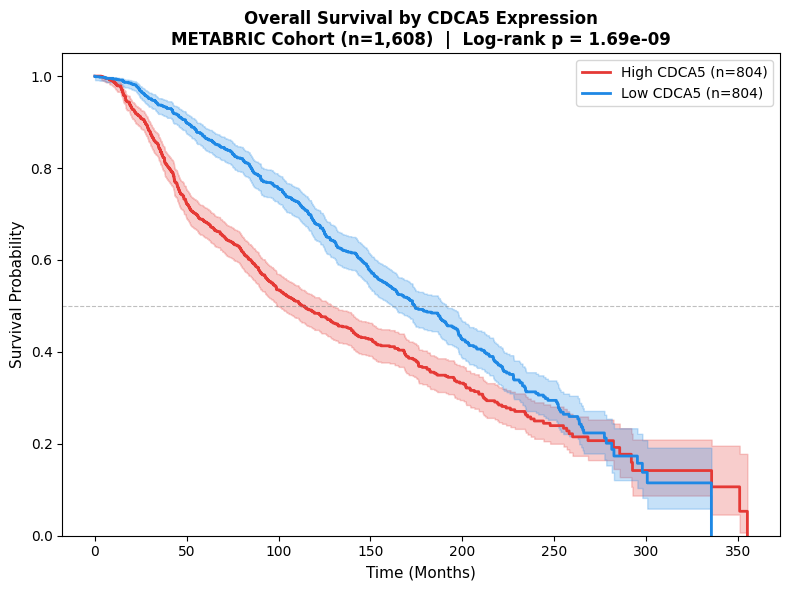

Log-rank p-value: 1.6890e-09
CDCA5 median expression (z-score): 0.0212


In [14]:
#Figure 2: CDCA5 High vs Low Survival
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# ── Split on CDCA5 median expression ──
cdca5_median = merged_clean["CDCA5"].median()
merged_clean["CDCA5_group"] = np.where(
    merged_clean["CDCA5"] >= cdca5_median,
    f"High CDCA5 (n={(merged_clean['CDCA5'] >= cdca5_median).sum()})",
    f"Low CDCA5 (n={(merged_clean['CDCA5'] < cdca5_median).sum()})"
)

high = merged_clean[merged_clean["CDCA5"] >= cdca5_median]
low  = merged_clean[merged_clean["CDCA5"] <  cdca5_median]

# ── Log-rank test ──
lr = logrank_test(
    high["OS_MONTHS"], low["OS_MONTHS"],
    high["OS_EVENT"],  low["OS_EVENT"]
)

# ── Plot ──
fig, ax = plt.subplots(figsize=(8, 6))
kmf = KaplanMeierFitter()

kmf.fit(high["OS_MONTHS"], high["OS_EVENT"],
        label=f"High CDCA5 (n={len(high)})")
kmf.plot_survival_function(ax=ax, color="#E53935", ci_show=True, linewidth=2)

kmf.fit(low["OS_MONTHS"], low["OS_EVENT"],
        label=f"Low CDCA5 (n={len(low)})")
kmf.plot_survival_function(ax=ax, color="#1E88E5", ci_show=True, linewidth=2)

ax.set_title(
    f"Overall Survival by CDCA5 Expression\n"
    f"METABRIC Cohort (n=1,608)  |  Log-rank p = {lr.p_value:.2e}",
    fontsize=12, fontweight="bold"
)
ax.set_xlabel("Time (Months)", fontsize=11)
ax.set_ylabel("Survival Probability", fontsize=11)
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)
ax.legend(loc="upper right", fontsize=10)

plt.tight_layout()
plt.savefig("KM_CDCA5_expression.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Log-rank p-value: {lr.p_value:.4e}")
print(f"CDCA5 median expression (z-score): {cdca5_median:.4f}")

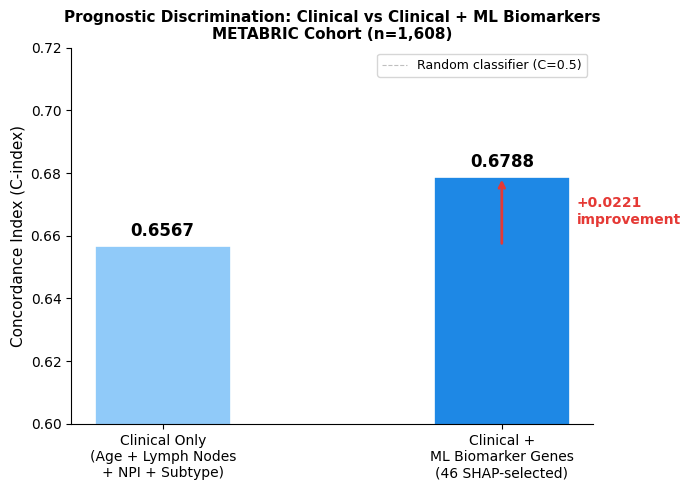

In [15]:
import matplotlib.pyplot as plt
import numpy as np

models = ["Clinical Only\n(Age + Lymph Nodes\n+ NPI + Subtype)",
          "Clinical +\nML Biomarker Genes\n(46 SHAP-selected)"]
cindex = [0.6567, 0.6788]
colors = ["#90CAF9", "#1E88E5"]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(models, cindex, color=colors, width=0.4,
              edgecolor="white", linewidth=1.2)

# Annotate bar values
for bar, val in zip(bars, cindex):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.002,
            f"{val:.4f}", ha="center", va="bottom",
            fontsize=12, fontweight="bold")

# Improvement arrow
ax.annotate("",
    xy=(1, cindex[1]),
    xytext=(1, cindex[0]),
    arrowprops=dict(arrowstyle="->", color="#E53935", lw=2))
ax.text(1.22, (cindex[0] + cindex[1])/2,
        f"+{cindex[1]-cindex[0]:.4f}\nimprovement",
        color="#E53935", fontsize=10, fontweight="bold", va="center")

ax.set_ylim(0.60, 0.72)
ax.set_ylabel("Concordance Index (C-index)", fontsize=11)
ax.set_title(
    "Prognostic Discrimination: Clinical vs Clinical + ML Biomarkers\n"
    "METABRIC Cohort (n=1,608)",
    fontsize=11, fontweight="bold"
)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8,
           alpha=0.5, label="Random classifier (C=0.5)")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("cindex_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
# Run this before your session disconnects
from google.colab import files

# Download all figures
for fname in ["KM_survival_by_subtype.png",
              "forest_plot_biomarkers.png",
              "KM_CDCA5_expression.png",
              "cindex_comparison.png",
              "metabric_survival_analysis.csv"]:
    files.download(fname)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>